# 01 · A geostatistics tour

petekTools is the *scattered-data gridding & geostatistics* layer of the stack.
This notebook walks the full geostat front-door end to end on **fully synthetic
data**:

1. build a target `Lattice`,
2. plant a synthetic field and sample a handful of "wells" from it,
3. fit an **experimental variogram** and a **model**,
4. estimate the field with **ordinary kriging** (+ its variance),
5. draw conditioned realizations with **sequential Gaussian simulation (SGS)**.

Everything is seeded, so the notebook reproduces bit-for-bit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

import petektools as pt
print("petektools", pt.__version__)

# petekTools fields come back as nested lists field[col][row] (ncol x nrow).
# For an areal map we want rows=y, cols=x, so we transpose to (nrow, ncol).
def as_map(field):
    return np.asarray(field, dtype=float).T

def show_map(ax, field, lat, title, cmap="viridis", **kw):
    x1 = lat.ncol * 50.0
    y1 = lat.nrow * 50.0
    im = ax.imshow(as_map(field), origin="lower", extent=[0, x1, 0, y1],
                   aspect="equal", cmap=cmap, **kw)
    ax.set_title(title)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    return im

petektools 0.2.0


## 1 · A target lattice

A `Lattice(xori, yori, xinc, yinc, ncol, nrow)` is a regular areal grid: node
`(col, row)` sits at `(xori + col*xinc, yori + row*yinc)`. Here: a 48×36 grid at
50 m spacing, origin at `(0, 0)` — a 2400 m × 1800 m area.

In [2]:
INC = 50.0
lat = pt.Lattice(0.0, 0.0, INC, INC, 48, 36)
print(f"lattice: {lat.ncol} x {lat.nrow} nodes, "
      f"{lat.ncol*INC:.0f} m x {lat.nrow*INC:.0f} m")

lattice: 48 x 36 nodes, 2400 m x 1800 m


## 2 · Plant a synthetic field, then sample it

We use a synthetic dome surface as the *unknown truth* — an elliptical four-way
closure with a little correlated noise. Then we drop 55 seeded "well" locations
and read the truth at each: those `[x, y, z]` triples are the only data the
geostat kernels will see.

In [3]:
noise_vg = pt.Variogram("spherical", 0.0, 1.0, 650.0)   # continuity of the noise
truth = pt.synth_dome_surface(lat, relief=90.0, aspect=1.6, tilt=6.0,
                              noise_variance=18.0, noise_variogram=noise_vg, seed=7)
truth_arr = np.asarray(truth, dtype=float)

# 55 seeded wells inside the area; sample the truth at the nearest node.
wells = pt.place_wells(80.0, 80.0, 2320.0, 1720.0, n=55, seed=11)
coords = []
for x, y in wells:
    i = min(max(int(round(x / INC)), 0), lat.ncol - 1)
    j = min(max(int(round(y / INC)), 0), lat.nrow - 1)
    coords.append([x, y, float(truth_arr[i, j])])
zvals = np.array([c[2] for c in coords])
print(f"{len(coords)} samples, z range {zvals.min():.1f} .. {zvals.max():.1f}")

55 samples, z range -3.5 .. 87.9


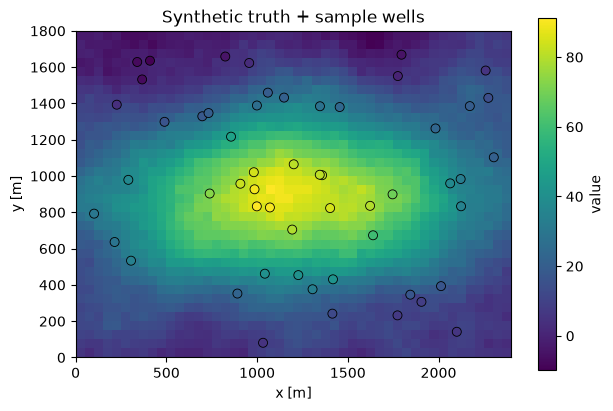

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
im = show_map(ax, truth, lat, "Synthetic truth + sample wells")
xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
ax.scatter(xs, ys, c=zvals, cmap="viridis", edgecolor="k", s=42, linewidth=0.6)
fig.colorbar(im, ax=ax, label="value", shrink=0.85)
plt.tight_layout(); plt.show()

## 3 · Experimental variogram

`experimental_variogram(coords, lag, n_lags)` computes an omnidirectional
experimental variogram: `n_lags` bins of width `lag`, each reporting mean pair
separation and semivariance. It quantifies how quickly the property decorrelates
with distance.

In [5]:
exp = pt.experimental_variogram(coords, lag=90.0, n_lags=12)
print("populated lags:", len(exp.lags))
for h, g, c in zip(exp.lags, exp.semivariances, exp.counts):
    print(f"  h={h:7.1f} m   gamma={g:8.2f}   pairs={c}")

populated lags: 12
  h=   59.2 m   gamma=    9.31   pairs=7
  h=  135.7 m   gamma=   34.07   pairs=32
  h=  225.7 m   gamma=  107.54   pairs=38
  h=  321.9 m   gamma=  149.78   pairs=59
  h=  408.0 m   gamma=  549.30   pairs=84
  h=  495.6 m   gamma=  679.64   pairs=79
  h=  589.3 m   gamma=  895.14   pairs=99
  h=  675.5 m   gamma= 1000.09   pairs=92
  h=  762.3 m   gamma= 1218.09   pairs=107
  h=  857.2 m   gamma= 1165.85   pairs=107
  h=  947.0 m   gamma= 1029.12   pairs=96
  h= 1032.8 m   gamma= 1225.31   pairs=96


## 4 · Fit a model

`Variogram.fit(model, experimental)` fits `(nugget, sill, range)` by pair-count
weighted least squares. We fit a **spherical** model and overlay it on the
experimental points.

spherical fit: nugget=0.00  sill=1314.10  range=1294.3 m


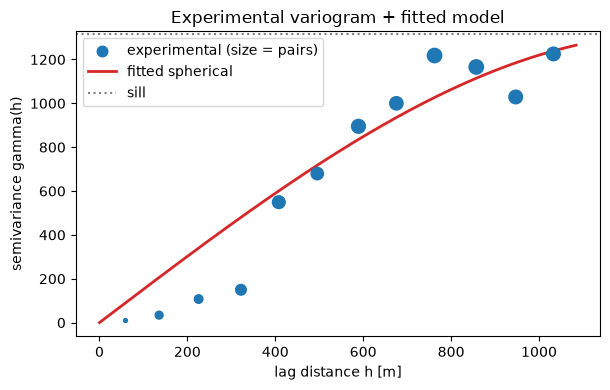

In [6]:
vg = pt.Variogram.fit("spherical", exp)
print(f"spherical fit: nugget={vg.nugget:.2f}  sill={vg.sill:.2f}  range={vg.range:.1f} m")

def spherical(h, nugget, sill, rng):
    h = np.asarray(h, float)
    out = nugget + sill * (1.5 * h / rng - 0.5 * (h / rng) ** 3)
    return np.where(h >= rng, nugget + sill, out)

hh = np.linspace(0, max(exp.lags) * 1.05, 200)
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.scatter(exp.lags, exp.semivariances, s=[max(8, c) for c in exp.counts],
           color="#1f77b4", zorder=3, label="experimental (size = pairs)")
ax.plot(hh, spherical(hh, vg.nugget, vg.sill, vg.range), color="#d62728",
        lw=2, label="fitted spherical")
ax.axhline(vg.nugget + vg.sill, ls=":", color="gray", label="sill")
ax.set_xlabel("lag distance h [m]"); ax.set_ylabel("semivariance gamma(h)")
ax.set_title("Experimental variogram + fitted model"); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Ordinary kriging

`local_kriging_grid(coords, lattice, variogram, max_neighbours, radius)` runs
moving-neighbourhood ordinary kriging and returns **two** `ncol × nrow` fields:
the estimate and the kriging variance. A node with no data within `radius` is
`NaN` in both. Kriging is the *best linear unbiased* estimate — smooth, and it
honours the samples.

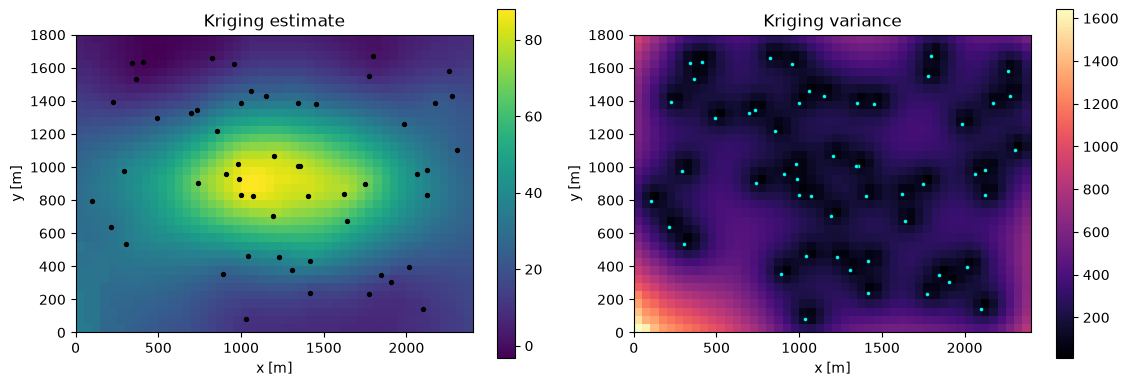

In [7]:
est, var = pt.local_kriging_grid(coords, lat, vg, max_neighbours=16, radius=900.0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
im0 = show_map(axes[0], est, lat, "Kriging estimate")
axes[0].scatter(xs, ys, c="k", s=8)
fig.colorbar(im0, ax=axes[0], shrink=0.85)
im1 = show_map(axes[1], var, lat, "Kriging variance", cmap="magma")
axes[1].scatter(xs, ys, c="cyan", s=8, edgecolor="k", linewidth=0.3)
fig.colorbar(im1, ax=axes[1], shrink=0.85)
plt.tight_layout(); plt.show()

The variance map tells the story kriging is famous for: it is **low near the
wells** and grows into the gaps — an honest map of *where the estimate is well
constrained*.

## 6 · Sequential Gaussian simulation

Kriging gives one smooth estimate; **SGS** draws many equiprobable realizations
that all honour the data *and* reproduce the variogram's texture. `sgs` conditions
exactly on the samples and is seeded (a seed reproduces the field bit-for-bit).

The model fed to SGS should be fitted on **normal-score** data (total sill ~1), so
we transform the samples to normal scores first, refit, and simulate. `sgs`
returns the field back in **data space**.

In [8]:
# Normal-score transform of the sampled values (rank -> Gaussian quantile).
ranks = zvals.argsort().argsort()
nscore = np.array([NormalDist().inv_cdf((r + 0.5) / len(zvals)) for r in ranks])
ns_coords = [[coords[i][0], coords[i][1], float(nscore[i])] for i in range(len(coords))]

exp_ns = pt.experimental_variogram(ns_coords, lag=90.0, n_lags=12)
vg_ns = pt.Variogram.fit("spherical", exp_ns)
print(f"normal-score model: nugget={vg_ns.nugget:.2f} sill={vg_ns.sill:.2f} "
      f"range={vg_ns.range:.1f} m  (sill ~ 1 as expected for normal scores)")

normal-score model: nugget=0.00 sill=2.30 range=2070.8 m  (sill ~ 1 as expected for normal scores)


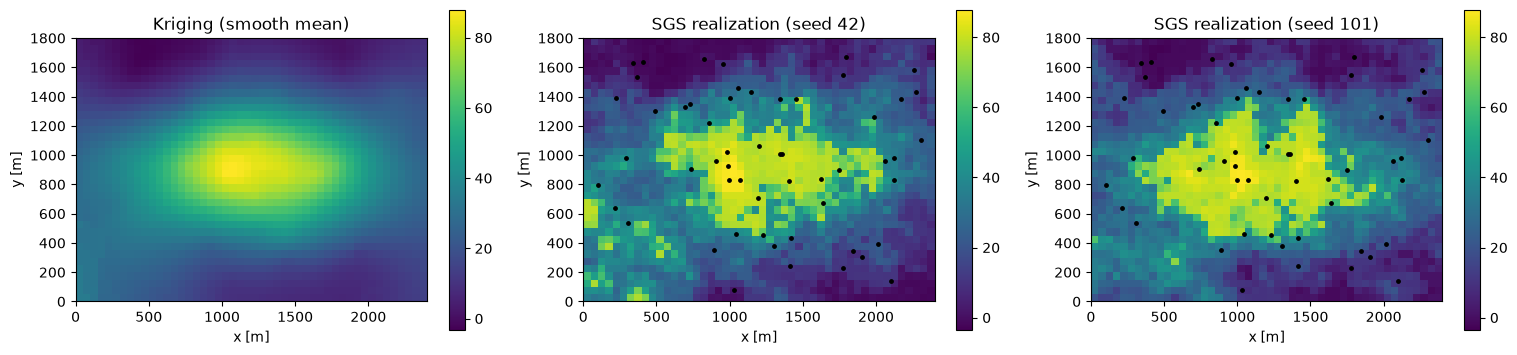

In [9]:
reals = [pt.sgs(coords, lat, vg_ns, max_neighbours=16, radius=900.0, seed=s)
         for s in (42, 101)]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
im = show_map(axes[0], est, lat, "Kriging (smooth mean)")
fig.colorbar(im, ax=axes[0], shrink=0.8)
for k, r in enumerate(reals, start=1):
    im = show_map(axes[k], r, lat, f"SGS realization (seed {(42,101)[k-1]})")
    axes[k].scatter(xs, ys, c="k", s=6)
    fig.colorbar(im, ax=axes[k], shrink=0.8)
plt.tight_layout(); plt.show()

Each realization is rougher than the kriged mean — it carries the full
variogram texture — yet all of them collapse to the same values at the wells.
Averaging many realizations would recover something close to the kriged estimate,
while their spread at each node echoes the kriging variance.

In [10]:
# Reproducibility + conditioning sanity check.
same = pt.sgs(coords, lat, vg_ns, max_neighbours=16, radius=900.0, seed=42)
print("same seed reproduces field:",
      np.allclose(np.asarray(same), np.asarray(reals[0])))

r0 = np.asarray(reals[0], dtype=float)
resid = []
for x, y, z in coords:
    i = min(max(int(round(x / INC)), 0), lat.ncol - 1)
    j = min(max(int(round(y / INC)), 0), lat.nrow - 1)
    resid.append(r0[i, j] - z)
print(f"max |realization - data| at nearest node: {np.max(np.abs(resid)):.3f}")

same seed reproduces field: True
max |realization - data| at nearest node: 0.000


### Recap

- `Lattice` — the target geometry every kernel speaks.
- `experimental_variogram` -> `Variogram.fit` — quantify and model spatial
  continuity.
- `local_kriging_grid` — the best linear unbiased estimate **plus** its variance.
- `sgs` — seeded, data-conditioned stochastic realizations with the right texture.

All deterministic, all type-agnostic (`[x,y,z]` in, gridded field out), all on
synthetic data.